In [1]:
import polars as pl
import os
from PIL import Image
import sys
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

sys.path.append("..")
from src.viewpoint.model import ViewpointClassifier
from src.viewpoint.train import make_dataloader
from argparse import Namespace
from tqdm.auto import tqdm

BASEPATH = "/home/affahrizain/projects/datasets/geotir"
DEVICE = "cuda"

/home/affahrizain/projects/multi-pov-ir/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
args = Namespace(
    data_path=os.path.join(BASEPATH, "jp_gldv_mp16_merged_scenetags.csv"),
    base_img_path=BASEPATH,
    batch_size=128,
    ckpt_path="../checkpoints/viewpoint_multihead/viewpoint_best.pt",
)

In [3]:
df = pl.read_csv(args.data_path)
strat_key = df["scene_type"] + "_" + df["viewpoint_type"]
_, test = train_test_split(df, test_size=0.05, random_state=42, stratify=strat_key)
testloader = make_dataloader(test, args.base_img_path, args.batch_size, split="test")

In [4]:
model = ViewpointClassifier().to(DEVICE)
model.load_state_dict(torch.load(args.ckpt_path))
model.eval()

ViewpointClassifier(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU

In [5]:
tasks = ["scene", "viewpoint"]
all_labels = {t: [] for t in tasks}
all_preds = {t: [] for t in tasks}

for inp, scene_lbl, viewpoint_lbl in tqdm(testloader, desc="Inference"):
    inp, scene_lbl, viewpoint_lbl = (
        inp.to(DEVICE),
        scene_lbl.to(DEVICE),
        viewpoint_lbl.to(DEVICE),
    )
    scene_out, viewpoint_out = model(inp)
    scene_preds = torch.argmax(scene_out, dim=1)
    viewpoint_preds = torch.argmax(viewpoint_out, dim=1)

    all_preds["scene"].append(scene_preds.cpu())
    all_preds["viewpoint"].append(viewpoint_preds.cpu())
    all_labels["scene"].append(scene_lbl.cpu())
    all_labels["viewpoint"].append(viewpoint_lbl.cpu())

# all_preds = torch.cat(all_preds).numpy()
# all_labels = torch.cat(all_labels).numpy()

Inference: 100%|██████████| 86/86 [00:24<00:00,  3.50it/s]


In [6]:
scene_gt = torch.cat(all_labels["scene"]).numpy()
viewpoint_gt = torch.cat(all_labels["viewpoint"]).numpy()
scene_preds = torch.cat(all_preds["scene"]).numpy()
viewpoint_preds = torch.cat(all_preds["viewpoint"]).numpy()

In [7]:
scene_prec, scene_recall, scene_f1, _ = precision_recall_fscore_support(
    scene_gt, scene_preds, average="macro", zero_division=0
)
viewpoint_prec, viewpoint_recall, viewpoint_f1, _ = precision_recall_fscore_support(
    viewpoint_gt, viewpoint_preds, average="macro", zero_division=0
)
print(
    f"  [scene] Precision: {scene_prec:.4f} | "
    f"Recall: {scene_recall:.4f} | F1: {scene_f1:.4f}"
)
print(
    f"  [viewpoint] Precision: {viewpoint_prec:.4f} | "
    f"Recall: {viewpoint_recall:.4f} | F1: {viewpoint_f1:.4f}"
)

  [scene] Precision: 0.8426 | Recall: 0.9192 | F1: 0.8727
  [viewpoint] Precision: 0.6118 | Recall: 0.8860 | F1: 0.6514


In [12]:
test = test.with_columns(
    [
        pl.Series("pred_scene", scene_preds.tolist()),
        pl.Series("pred_viewpoint", viewpoint_preds.tolist()),
    ]
)

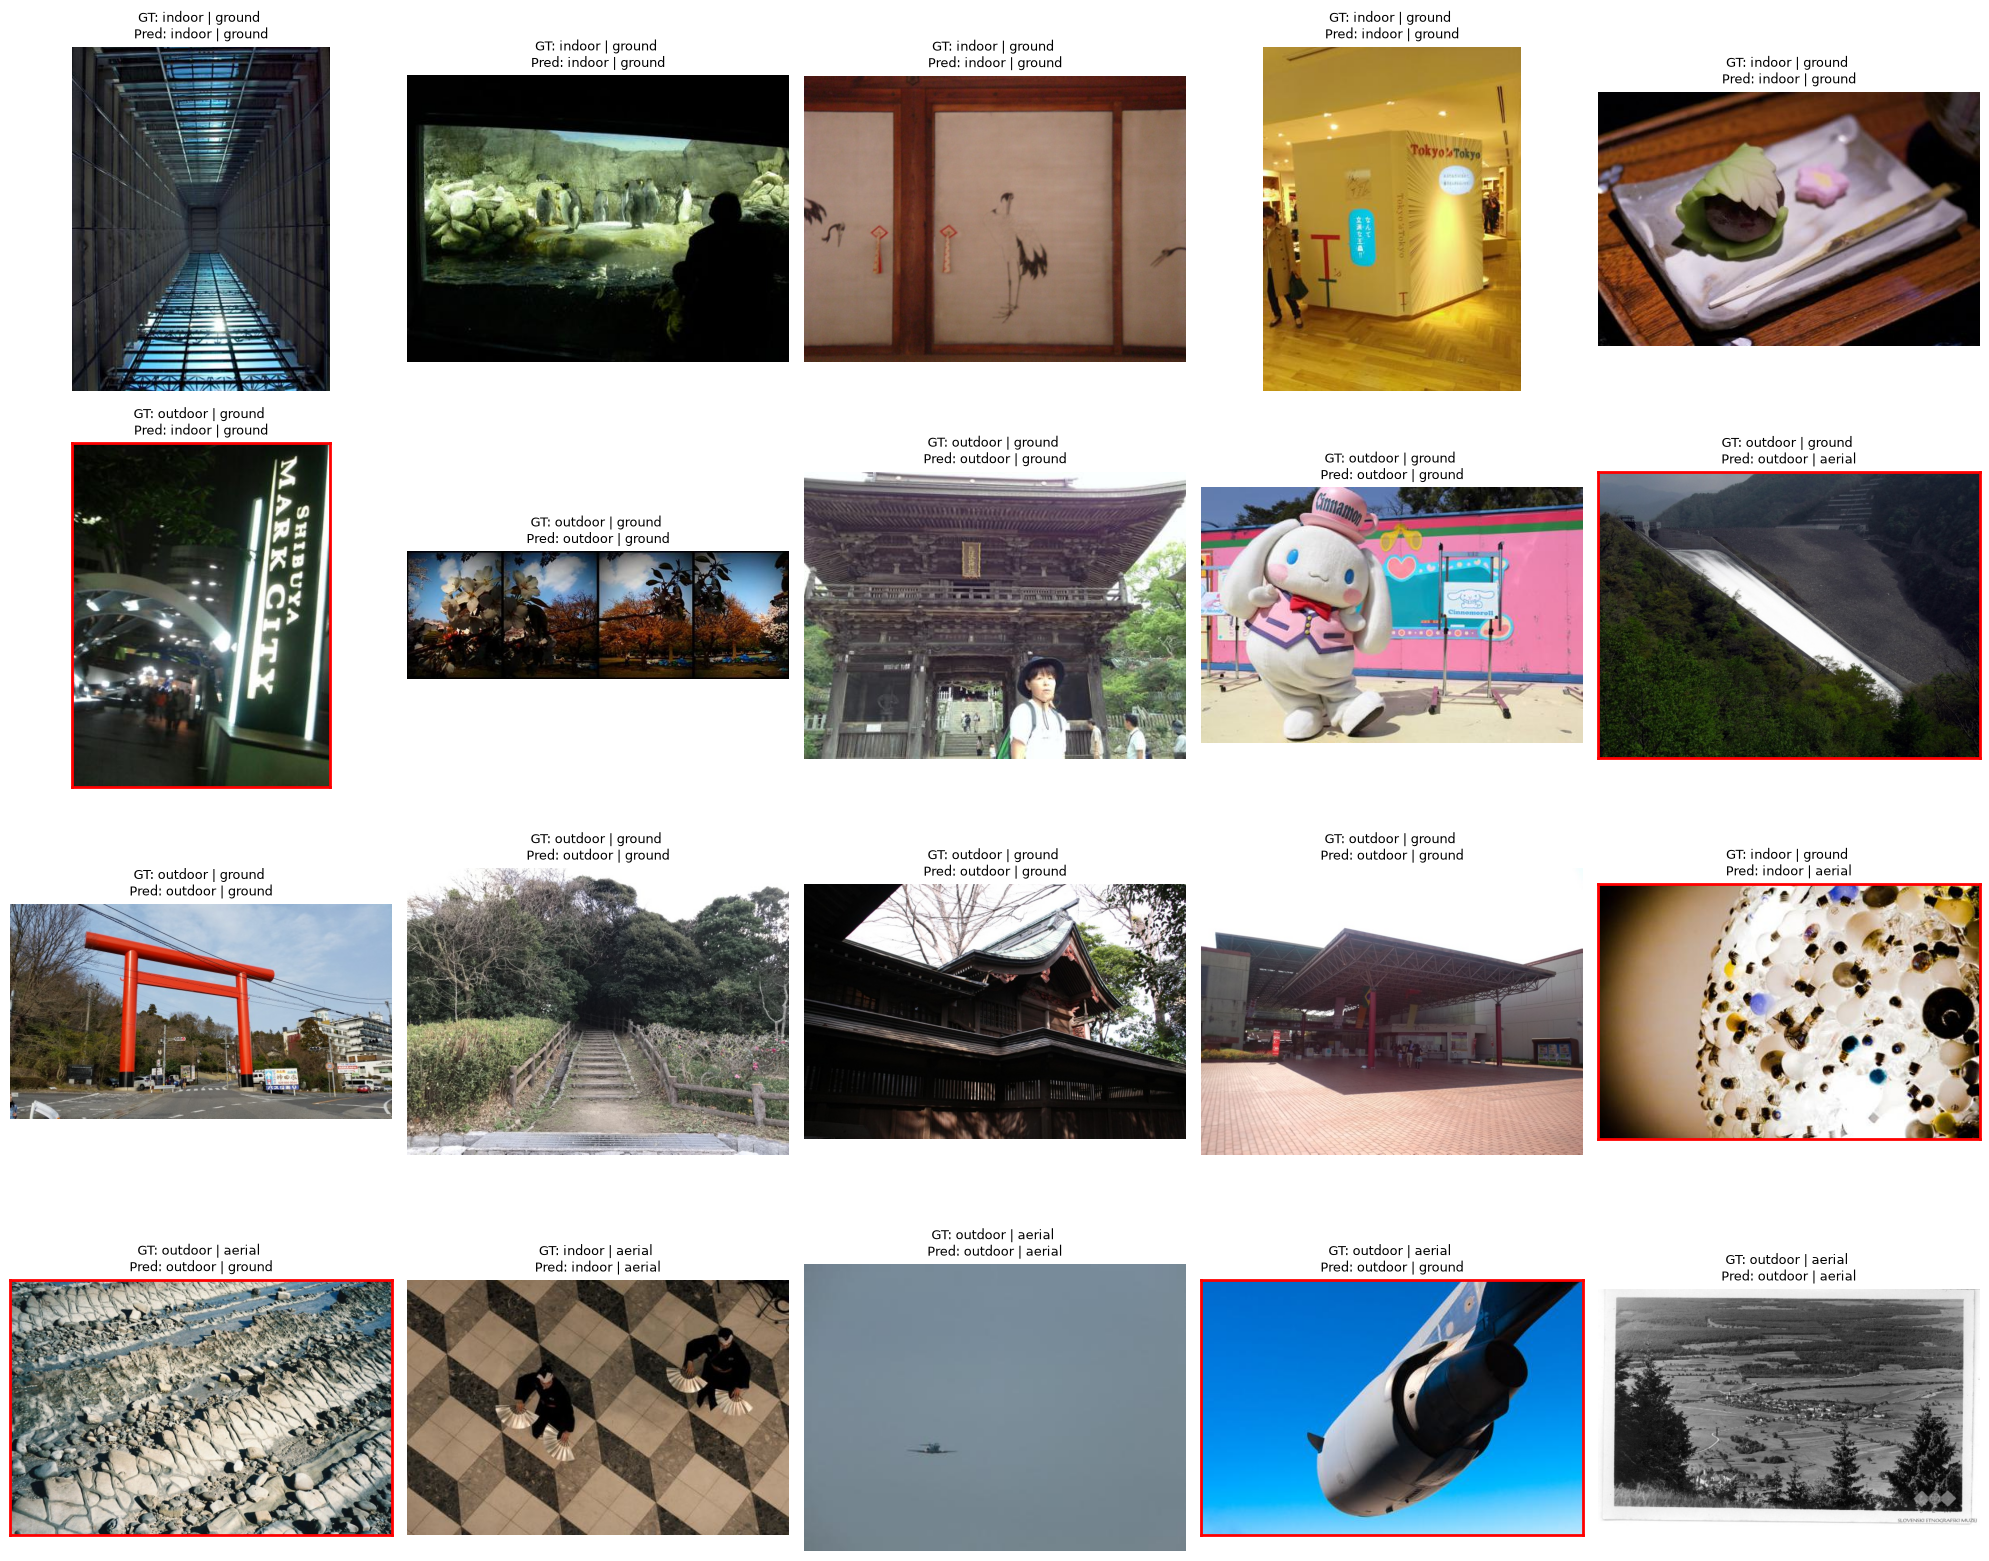

In [24]:
import matplotlib.pyplot as plt

ID2SCENE = {0: "indoor", 1: "outdoor"}
ID2VIEWPOINT = {0: "ground", 1: "aerial"}

test = test.with_columns(
    pl.Series("scene_pred", [ID2SCENE[i] for i in scene_preds.tolist()]),
    pl.Series(
        "viewpoint_pred", [ID2VIEWPOINT[i] for i in viewpoint_preds.tolist()]
    ),
)

categories = [
    ("scene_type", "indoor"),
    ("scene_type", "outdoor"),
    ("viewpoint_type", "ground"),
    ("viewpoint_type", "aerial"),
]

fig, ax = plt.subplots(4, 5, figsize=(20, 16))
for row, (col, label) in enumerate(categories):
    samples = test.filter(pl.col(col) == label).sample(5).to_dicts()
    for i, item in enumerate(samples):
        img = Image.open(
            os.path.join(BASEPATH, item["dataset"], item["src"], f"{item['id']}.jpg")
        )
        axis = ax[row, i]
        axis.imshow(img)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.set_title(
            f"GT: {item['scene_type']} | {item['viewpoint_type']} \nPred: {item['scene_pred']} | {item['viewpoint_pred']}",
            fontsize=9,
        )

        is_correct = (
            item["scene_type"] == item["scene_pred"]
            and item["viewpoint_type"] == item["viewpoint_pred"]
        )
        if not is_correct:
            for spine in axis.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor("red")
                spine.set_linewidth(2)
        else:
            for spine in axis.spines.values():
                spine.set_visible(False)


plt.tight_layout()
plt.show()